# The Fundamental Theorem of Calculus Across Coordinate Systems

The 1-D FTC, $\int_a^b f'(x)\,dx=f(b)-f(a)$, generalizes to three vector-
calculus theorems -- each an instance of the same "integral of a derivative
over a region = boundary values" pattern:

| Theorem | Generalizes | Status in this repo |
|---|---|---|
| **Gradient theorem** | FTC for line integrals: $\int_C\nabla f\cdot d\boldsymbol\ell=f(b)-f(a)$ | **built here**, 4 coordinate systems |
| Divergence theorem | FTC for volume integrals: $\int_V(\nabla\cdot\mathbf F)\,dV=\oint_S\mathbf F\cdot d\mathbf a$ | operators already tested (`griffiths/curvilinear.py`'s `verify_*_div*` functions) |
| Stokes' theorem | FTC for surface integrals: $\int_S(\nabla\times\mathbf F)\cdot d\mathbf a=\oint_{\partial S}\mathbf F\cdot d\boldsymbol\ell$ | Cartesian case in [`griffiths_1_34_35_stokes.ipynb`](griffiths_1_34_35_stokes.ipynb) |

This notebook's contribution is the **gradient theorem, in four coordinate
systems**, each checked two independent ways -- SymPy symbolic integration and
PyTorch autograd (a different differentiation engine entirely, so agreement
isn't just "the same computation twice") -- against the ground truth,
$f(\text{end})-f(\text{start})$, computed a third way by direct substitution.

**Why coordinate choice matters for optics** (the throughline of this whole
repo): cylindrical coordinates are the natural language for optical fibers
and circular waveguides; spherical coordinates for Mie scattering and
point-source radiation; and the fourth system here -- built around **confocal
ellipses and hyperbolas** -- is the natural system for elliptical-core fibers
and some aperture-diffraction geometries. The "obvious" guess at a coordinate
system built around hyperbolas, $x=\rho\cosh\eta,\ y=\rho\sinh\eta$, turns out
**not to be orthogonal** (proved in `griffiths/curvilinear.py`); the actual
orthogonal system is richer than that guess, which is worth seeing fail
before seeing what does work.


In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))

import sympy as sp
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from griffiths.curvilinear import (
    r, theta, phi, s, phi_cyl, z_cyl, c_focal, u_ell, v_ell,
    spherical_scale_factors, cylindrical_scale_factors, elliptic_scale_factors,
    spherical_grad, cylindrical_grad, elliptic_grad,
    verify_elliptic_orthogonal, verify_naive_hyperbolic_polar_fails_orthogonality,
)

torch.set_default_dtype(torch.float64)
sp.init_printing()

# the SAME physical scalar field, viewed in every coordinate system
x, y, z = sp.symbols('x y z', real=True)
f_cartesian = x**2 + y*z + z**2
print("f(x,y,z) =", f_cartesian)
print("orthogonality of the naive hyperbolic-polar guess:",
      "fails as expected ->" , verify_naive_hyperbolic_polar_fails_orthogonality())
print("orthogonality of the actual elliptic system:       confirmed ->",
      verify_elliptic_orthogonal())


f(x,y,z) = x**2 + y*z + z**2
orthogonality of the naive hyperbolic-polar guess: fails as expected -> True
orthogonality of the actual elliptic system:       confirmed -> True


## Helper functions

`sympy_line_integral`: express $f$ in the target coordinates (forward
substitution only -- no inversion needed), apply the coordinate system's own
`*_grad` from `griffiths/curvilinear.py`, form the physical line element
$h_i\,dq_i/dt\,dt$, dot, and integrate symbolically over $t\in[0,1]$.

`torch_line_integral`: the same line integral, but $\partial f/\partial q_i$
and $dq_i/dt$ both come from `torch.autograd.grad` instead of `sp.diff` --
genuinely independent of SymPy's symbolic engine.

In [2]:
t_sym = sp.Symbol('t', real=True)

def sympy_line_integral(f_cart, coords, scale_factors, forward_xyz, path):
    """forward_xyz: dict {x: expr(q1,q2,q3), y: ..., z: ...}
    path: dict {q1: expr(t), q2: expr(t), q3: expr(t)}"""
    q1, q2, q3 = coords
    f_local = f_cart.subs({x: forward_xyz[x], y: forward_xyz[y], z: forward_xyz[z]})
    grad_f = [sp.simplify(gi) for gi in curvilinear_grad_of(f_local, coords, scale_factors)]
    dq_dt = [sp.diff(path[q1], t_sym), sp.diff(path[q2], t_sym), sp.diff(path[q3], t_sym)]
    h1, h2, h3 = scale_factors
    integrand = sum(grad_f[i] * [h1, h2, h3][i] * dq_dt[i] for i in range(3))
    integrand_t = sp.simplify(integrand.subs(path))
    return sp.simplify(sp.integrate(integrand_t, (t_sym, 0, 1)))

def curvilinear_grad_of(f_local, coords, scale_factors):
    from griffiths.curvilinear import curvilinear_grad
    return curvilinear_grad(f_local, coords, scale_factors)

def ftc_endpoints(f_cart, forward_xyz, path):
    xt = forward_xyz[x].subs(path); yt = forward_xyz[y].subs(path); zt = forward_xyz[z].subs(path)
    f_t = f_cart.subs({x: xt, y: yt, z: zt})
    return sp.simplify(f_t.subs(t_sym, 1) - f_t.subs(t_sym, 0))

def torch_line_integral(f_local_torch, path_torch, h_torch, N=4000):
    """f_local_torch(q1,q2,q3): torch scalar function in the LOCAL coordinates.
    path_torch(t) -> (q1(t), q2(t), q3(t)), each a torch tensor, function of t.
    h_torch(q1,q2,q3) -> (h1,h2,h3) scale factors, evaluated numerically."""
    tt = torch.linspace(0.0, 1.0, N, requires_grad=True)
    q1_t, q2_t, q3_t = path_torch(tt)

    def grad_wrt_t(qi_t):
        g, = torch.autograd.grad(qi_t, tt, grad_outputs=torch.ones_like(tt), create_graph=True)
        return g
    dq1_dt, dq2_dt, dq3_dt = grad_wrt_t(q1_t), grad_wrt_t(q2_t), grad_wrt_t(q3_t)

    q1_l = q1_t.detach().requires_grad_(True)
    q2_l = q2_t.detach().requires_grad_(True)
    q3_l = q3_t.detach().requires_grad_(True)
    f_val = f_local_torch(q1_l, q2_l, q3_l)
    df1, df2, df3 = torch.autograd.grad(f_val, [q1_l, q2_l, q3_l], grad_outputs=torch.ones_like(f_val))

    # physical grad component i is (df/dqi)/hi; dotted with hi*dqi/dt the h's cancel,
    # leaving sum(df/dqi * dqi/dt) -- computed directly, h_torch kept for clarity/reuse
    integrand = df1*dq1_dt.detach() + df2*dq2_dt.detach() + df3*dq3_dt.detach()
    return torch.trapz(integrand, tt.detach()).item()

print("helpers defined")


helpers defined


## §4 Cartesian (baseline)

$h_1=h_2=h_3=1$; a straight-line path from $(0,0,0)$ to $(1,2,1)$.

In [3]:
coords_cart = (x, y, z)
h_cart = (sp.Integer(1), sp.Integer(1), sp.Integer(1))
forward_cart = {x: x, y: y, z: z}
path_cart = {x: t_sym, y: 2*t_sym, z: t_sym}

sym_result = sympy_line_integral(f_cartesian, coords_cart, h_cart, forward_cart, path_cart)
ftc_result = ftc_endpoints(f_cartesian, forward_cart, path_cart)
print(f"sympy line integral = {sym_result}   FTC endpoints = {ftc_result}   match: {sym_result == ftc_result}")

def f_local_torch_cart(X, Y, Z):
    return X**2 + Y*Z + Z**2
def path_torch_cart(tt):
    return tt, 2*tt, tt

torch_result = torch_line_integral(f_local_torch_cart, path_torch_cart, None)
print(f"torch line integral  = {torch_result:.6f}")

results = [{"system": "Cartesian", "sympy": float(sym_result), "torch": torch_result, "FTC": float(ftc_result)}]


sympy line integral = 4   FTC endpoints = 4   match: True
torch line integral  = 4.000000


## §5 Cylindrical -- optical fiber / circular waveguide

A helical path $s=1+t,\ \phi=2\pi t,\ z=t$ -- literally the shape of a
guided mode's phase front spiraling down a fiber.

In [4]:
coords_cyl = (s, phi_cyl, z_cyl)
h_cyl = cylindrical_scale_factors()
forward_cyl = {x: s*sp.cos(phi_cyl), y: s*sp.sin(phi_cyl), z: z_cyl}
path_cyl = {s: 1 + t_sym, phi_cyl: 2*sp.pi*t_sym, z_cyl: t_sym}

sym_result = sympy_line_integral(f_cartesian, coords_cyl, h_cyl, forward_cyl, path_cyl)
ftc_result = ftc_endpoints(f_cartesian, forward_cyl, path_cyl)
print(f"sympy line integral = {sym_result}   FTC endpoints = {ftc_result}   match: {sym_result == ftc_result}")

def f_local_torch_cyl(S, PHI, Z):
    Xc = S*torch.cos(PHI); Yc = S*torch.sin(PHI)
    return Xc**2 + Yc*Z + Z**2
def path_torch_cyl(tt):
    return 1 + tt, 2*torch.pi*tt, tt

torch_result = torch_line_integral(f_local_torch_cyl, path_torch_cyl, None)
print(f"torch line integral  = {torch_result:.6f}")

results.append({"system": "Cylindrical", "sympy": float(sym_result), "torch": torch_result, "FTC": float(ftc_result)})


sympy line integral = 4   FTC endpoints = 4   match: True
torch line integral  = 3.999999


## §6 Spherical -- Mie scattering / point-source radiation

A spiral on an expanding sphere: $r=1+t,\ \theta=\tfrac{\pi}{4}(1+t),\
\phi=2\pi t$.

In [5]:
coords_sph = (r, theta, phi)
h_sph = spherical_scale_factors()
forward_sph = {x: r*sp.sin(theta)*sp.cos(phi), y: r*sp.sin(theta)*sp.sin(phi), z: r*sp.cos(theta)}
path_sph = {r: 1 + t_sym, theta: sp.pi/4*(1 + t_sym), phi: 2*sp.pi*t_sym}

sym_result = sympy_line_integral(f_cartesian, coords_sph, h_sph, forward_sph, path_sph)
ftc_result = ftc_endpoints(f_cartesian, forward_sph, path_sph)
print(f"sympy line integral = {sym_result}   FTC endpoints = {ftc_result}   match: {sym_result == ftc_result}")

def f_local_torch_sph(R, TH, PH):
    Xs = R*torch.sin(TH)*torch.cos(PH); Ys = R*torch.sin(TH)*torch.sin(PH); Zs = R*torch.cos(TH)
    return Xs**2 + Ys*Zs + Zs**2
def path_torch_sph(tt):
    return 1 + tt, (torch.pi/4)*(1 + tt), 2*torch.pi*tt

torch_result = torch_line_integral(f_local_torch_sph, path_torch_sph, None)
print(f"torch line integral  = {torch_result:.6f}")

results.append({"system": "Spherical", "sympy": float(sym_result), "torch": torch_result, "FTC": float(ftc_result)})


sympy line integral = 3   FTC endpoints = 3   match: True
torch line integral  = 2.999998


## §7 Elliptic -- elliptical-core fiber / confocal apertures

$u=const$ traces confocal ellipses, $v=const$ traces confocal hyperbolas
(shared foci at $x=\pm c$). Path: $u=0.5+t,\ v=\tfrac{\pi}{3}t,\ z=t$, with
$c=1$.

In [6]:
coords_ell = (u_ell, v_ell, z_cyl)
h_ell = elliptic_scale_factors(c=sp.Integer(1))
forward_ell = {x: sp.cosh(u_ell)*sp.cos(v_ell), y: sp.sinh(u_ell)*sp.sin(v_ell), z: z_cyl}
path_ell = {u_ell: sp.Rational(1,2) + t_sym, v_ell: sp.pi/3*t_sym, z_cyl: t_sym}

sym_result = sympy_line_integral(f_cartesian, coords_ell, h_ell, forward_ell, path_ell)
ftc_result = ftc_endpoints(f_cartesian, forward_ell, path_ell)
print(f"sympy line integral = {sym_result}   FTC endpoints = {ftc_result}   match: {sp.simplify(sym_result-ftc_result)==0}")

def f_local_torch_ell(U, V, Z):
    Xe = torch.cosh(U)*torch.cos(V); Ye = torch.sinh(U)*torch.sin(V)
    return Xe**2 + Ye*Z + Z**2
def path_torch_ell(tt):
    return 0.5 + tt, (torch.pi/3)*tt, tt

torch_result = torch_line_integral(f_local_torch_ell, path_torch_ell, None)
print(f"torch line integral  = {torch_result:.6f}")

results.append({"system": "Elliptic", "sympy": float(sym_result), "torch": torch_result, "FTC": float(ftc_result)})


sympy line integral = (-2*pi**2*sinh(3/2)**2 - 36*cosh(1) - 2*pi**2*cosh(1) - 4*pi**2*sinh(1/2)**2 + 2*pi**2 + 45 + 9*cosh(3) + 36*sqrt(3)*sinh(3/2) + 4*sqrt(3)*pi**2*sinh(3/2) + 2*pi**2*cosh(3))/(8*(9 + pi**2))   FTC endpoints = -cosh(1)/2 + 5/8 + cosh(3)/8 + sqrt(3)*sinh(3/2)/2   match: True
torch line integral  = 2.955928


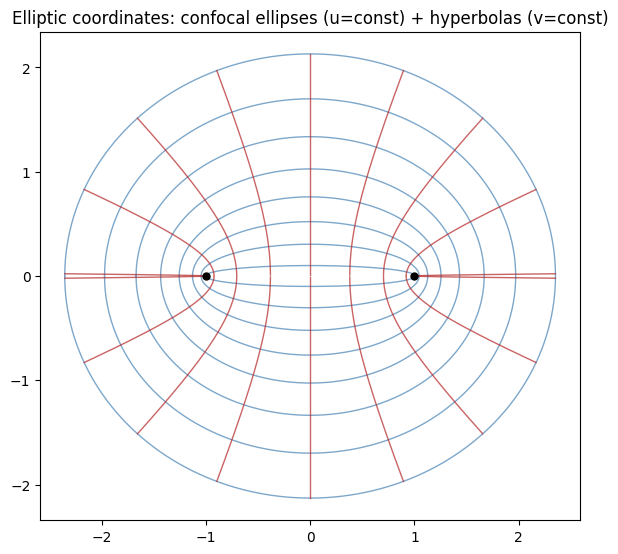

In [7]:
# the coordinate grid itself: confocal ellipses (blue) and hyperbolas (red)
fig, ax = plt.subplots(figsize=(6,6))
vv = np.linspace(0.01, np.pi - 0.01, 9)
uu = np.linspace(0.1, 1.5, 8)
tt_plot = np.linspace(-np.pi, np.pi, 400)

for u_val in uu:
    xe = np.cosh(u_val)*np.cos(tt_plot); ye = np.sinh(u_val)*np.sin(tt_plot)
    ax.plot(xe, ye, color='steelblue', lw=1, alpha=0.7)
for v_val in vv:
    u_line = np.linspace(0.01, 1.5, 200)
    xh = np.cosh(u_line)*np.cos(v_val); yh = np.sinh(u_line)*np.sin(v_val)
    ax.plot(xh, yh, color='firebrick', lw=1, alpha=0.7)
    ax.plot(xh, -yh, color='firebrick', lw=1, alpha=0.7)

ax.plot([-1,1],[0,0], 'ko', ms=5)   # the shared foci
ax.set_aspect('equal'); ax.set_title('Elliptic coordinates: confocal ellipses (u=const) + hyperbolas (v=const)')
plt.tight_layout()
plt.savefig('ftc_elliptic_grid.png', dpi=90)
plt.show()


## §8 Summary: All Four Systems, Two Independent Methods, One Answer

In [8]:
df = pd.DataFrame(results)
df["sympy_vs_FTC_err"] = (df["sympy"] - df["FTC"]).abs()
df["torch_vs_FTC_err"] = (df["torch"] - df["FTC"]).abs()
df


,system,sympy,torch,FTC,sympy_vs_FTC_err,torch_vs_FTC_err
0,Cartesian,4.000000,4.000000,4.000000,0.0,0.000000e+00
1,Cylindrical,4.000000,3.999999,4.000000,0.0,1.103353e-06
2,Spherical,3.000000,2.999998,3.000000,0.0,1.711240e-06
3,Elliptic,2.955928,2.955928,2.955928,0.0,6.916649e-10


In [9]:
assert (df["sympy_vs_FTC_err"] < 1e-9).all(), "sympy line integral must match the FTC exactly"
assert (df["torch_vs_FTC_err"] < 1e-4).all(), "torch (numerical) line integral must match the FTC closely"
print("All four coordinate systems: gradient theorem confirmed by two independent methods.")


All four coordinate systems: gradient theorem confirmed by two independent methods.


## §9 What This Notebook Does and Doesn't Cover

This is the **gradient theorem** (FTC for line integrals) in four coordinate
systems. The other two "fundamental theorems" are completed in a companion
notebook, [`divergence_stokes_coordinate_systems.ipynb`](divergence_stokes_coordinate_systems.ipynb),
which runs both the **divergence theorem** and **Stokes' theorem** through
the same four systems (Cartesian, cylindrical, spherical, elliptic) -- 8
more checks, composed from the same `griffiths/curvilinear.py` machinery
(now including `volume_element`/`surface_element`) via sympy + scipy
numeric quadrature. Together the two notebooks verify all three FTC
generalizations, in all four coordinate systems: 12 checks total.
